In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
import regionmask
from datetime import datetime
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Define file paths for different scenarios
files_historical = 'D:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc'
files_SSP119 = 'D:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp119_r1i1p1f1_g025.nc'
files_SSP126 = 'D:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp126_r1i1p1f1_g025.nc'
files_SSP245 = 'D:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp245_r1i1p1f1_g025.nc'
files_SSP370 = 'D:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp370_r1i1p1f1_g025.nc'
files_SSP585 = 'D:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp585_r1i1p1f1_g025.nc'

# Function to load datasets from a list of file paths
def load_datasets(file_list):
    return xr.open_mfdataset(file_list, combine='by_coords', engine='netcdf4')

# Load datasets
dataset_historical = load_datasets(files_historical)
dataset_SSP119 = load_datasets(files_SSP119)
dataset_SSP126 = load_datasets(files_SSP126)
dataset_SSP245 = load_datasets(files_SSP245)
dataset_SSP370 = load_datasets(files_SSP370)
dataset_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")

Datasets successfully loaded!


In [2]:
# Thailand
thailand_lat_range = slice(5.5, 20.5)
thailand_lon_range = slice(97.5, 105.5)

# England (converted to 0-360 longitude)
england_lat_range = slice(49.5, 55.5)
england_lon_range = slice(353.5, 1.5)  # If using (-180, 180), keep (-6.5, 1.5)

# Amazon (converted to 0-360 longitude)
amazon_lat_range = slice(-10.0, 5.0)
amazon_lon_range = slice(285.0, 310.0)  # If using (-180, 180), keep (-75.0, -50.0)

# Philippines
philippines_lat_range = slice(5.0, 20.0)
philippines_lon_range = slice(115.0, 130.0)


In [3]:
print("Longitude range:", dataset_historical.lon.min().values, "to", dataset_historical.lon.max().values)
print("Latitude range:", dataset_historical.lat.min().values, "to", dataset_historical.lat.max().values)


Longitude range: 1.25 to 358.75
Latitude range: -88.75 to 88.75


In [4]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = dataset_historical.coords['lon']
lat = dataset_historical.coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [5]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)

areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)

<xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


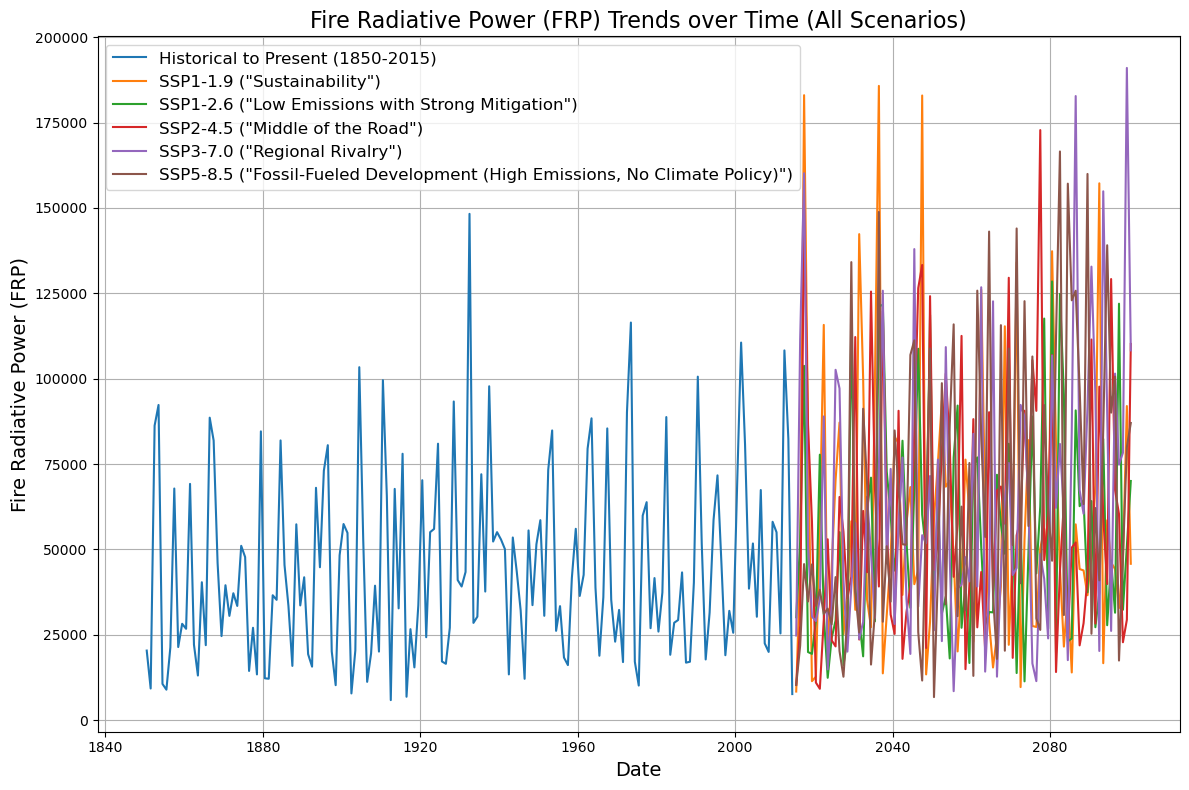

In [6]:
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

def calculate_frp_from_fwi(A, b, fwi_values):
    return 10 ** (A * fwi_values + b)

def plot_frp_trends(datasets, labels, scenario_coefficients, title):
    plt.figure(figsize=(12, 8))

    for dataset, label in zip(datasets, labels):
        # Convert cftime.DatetimeNoLeap to Python datetime
        time_data = [datetime(t.year, t.month, t.day) for t in dataset['time'].values]

        # Calculate mean FWI over Thailand
        fwi_mean = dataset['fwisa'].where(
            (dataset.lat >= 5) & (dataset.lat <= 21) &
            (dataset.lon >= 97) & (dataset.lon <= 106),
            drop=True
        ).mean(dim=['lat', 'lon']).values

        # Choose suitable coefficients (use historical coefficients as default)
        A, b = scenario_coefficients.get(label, (0.0665, 3.2044)) 

        # Convert FWI to FRP
        frp_mean = calculate_frp_from_fwi(A, b, fwi_mean)

        # Plot FRP instead of FWI
        plt.plot(time_data, frp_mean, label=label)

    # Customize plot
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid()
    plt.tight_layout()
    plt.show()

# Define coefficients clearly (assume same seasonal scenario used for all)
scenario_coefficients = {
    'Historical to Present (1850-2015)': (0.0665, 3.2044),
    'SSP1-1.9 ("Sustainability")': (0.0665, 3.2044),
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")': (0.0665, 3.2044),
    'SSP2-4.5 ("Middle of the Road")': (0.0665, 3.2044),
    'SSP3-7.0 ("Regional Rivalry")': (0.0665, 3.2044),
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")': (0.0665, 3.2044)
}

# Group datasets and labels clearly
datasets_all_scenarios = (
    [dataset_historical] + [dataset_SSP119] + [dataset_SSP126] + [dataset_SSP245] +
    [dataset_SSP370] + [dataset_SSP585]
)

labels_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability")',
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road")',
    'SSP3-7.0 ("Regional Rivalry")',
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")'
]

# Plot clearly the FRP trends for all scenarios
plot_frp_trends(
    datasets_all_scenarios, 
    labels_all_scenarios, 
    scenario_coefficients,
    'Fire Radiative Power (FRP) Trends over Time (All Scenarios)'
)


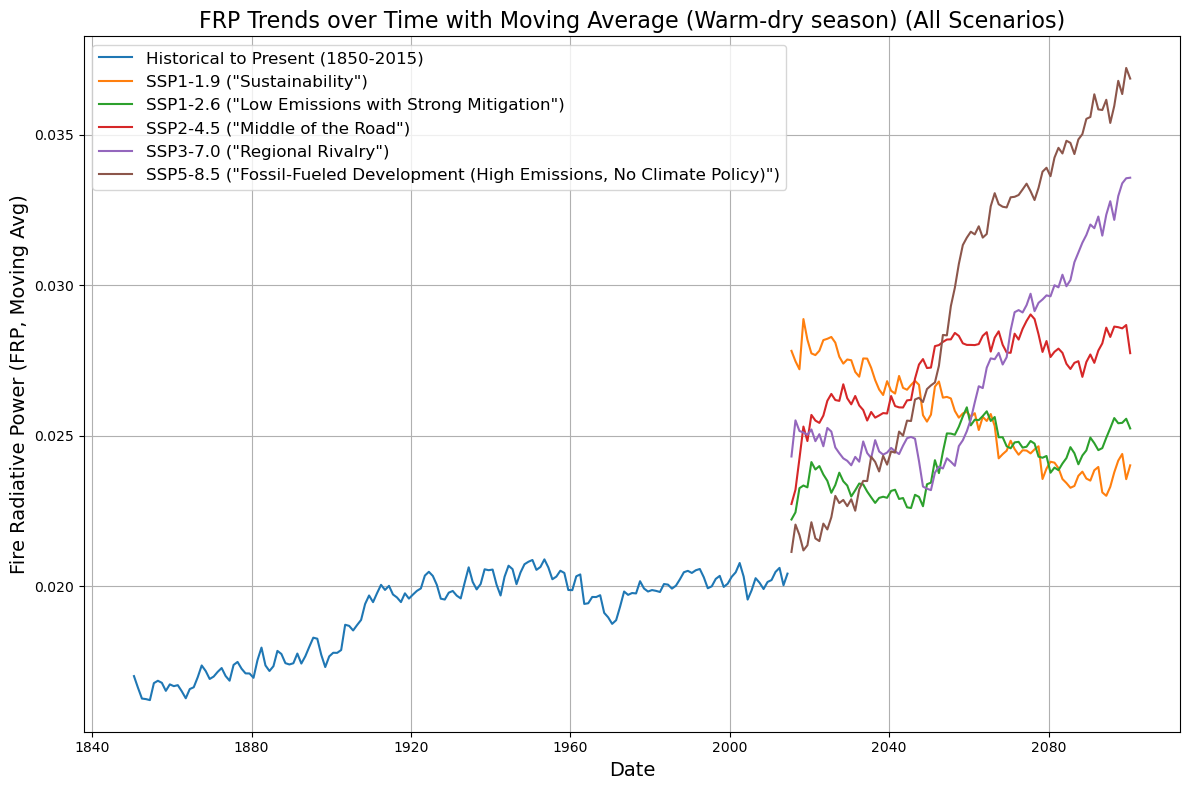

In [7]:
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import pandas as pd

def calculate_frp_from_fwi(A, b, fwi_values):
    return 10 ** (A * fwi_values + b)

def plot_frp_trends_moving_average(datasets, labels, scenario_coefficients, title, window=12):
    plt.figure(figsize=(12, 8))

    for dataset, label in zip(datasets, labels):
        # Convert cftime.DatetimeNoLeap to Python datetime
        time_data = [datetime(t.year, t.month, t.day) for t in dataset['time'].values]

        # Calculate mean FWI over Thailand
        fwi_mean = dataset['fwisa'].where(
            (dataset.lat >= 5) & (dataset.lat <= 21) &
            (dataset.lon >= 97) & (dataset.lon <= 106),
            drop=True
        ).mean(dim=['lat', 'lon']).values

        # Select coefficients (historical by default, adjust as needed)
        A, b = scenario_coefficients.get(label, (0.0665, 3.2044))

        # Convert FWI to FRP
        frp_mean = calculate_frp_from_fwi(A, b, fwi_mean)

        # Compute moving average (clearly using Pandas for simplicity)
        frp_series = pd.Series(frp_mean)
        frp_ma = frp_series.rolling(window=window, center=True, min_periods=1).mean()

        # Plot moving average clearly
        plt.plot(time_data, frp_ma, label=label)

    # Customize plot clearly
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP, Moving Avg)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid()
    plt.tight_layout()
    plt.show()

# Define coefficients clearly (adjust if you have scenario-specific values)
scenario_coefficients_warmdry = {
    'Historical to Present (1850-2015)': (0.0685, -3.2044),
    'SSP1-1.9 ("Sustainability")': (0.0685, -3.2044),
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")': (0.0685, -3.2044),
    'SSP2-4.5 ("Middle of the Road")': (0.0685, -3.2044),
    'SSP3-7.0 ("Regional Rivalry")': (0.0685, -3.2044),
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")': (0.0685, -3.2044)
}

# Group datasets and labels clearly
datasets_all_scenarios = (
    [dataset_historical] + [dataset_SSP119] + [dataset_SSP126] + [dataset_SSP245] +
    [dataset_SSP370] + [dataset_SSP585]
)

labels_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability")',
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road")',
    'SSP3-7.0 ("Regional Rivalry")',
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")'
]


# Plot FRP trends clearly with moving average
plot_frp_trends_moving_average(
    datasets_all_scenarios,
    labels_all_scenarios,
    scenario_coefficients_warmdry,
    'FRP Trends over Time with Moving Average (Warm-dry season) (All Scenarios)',
    window=60  # 12-month moving average (adjust as desired)
)


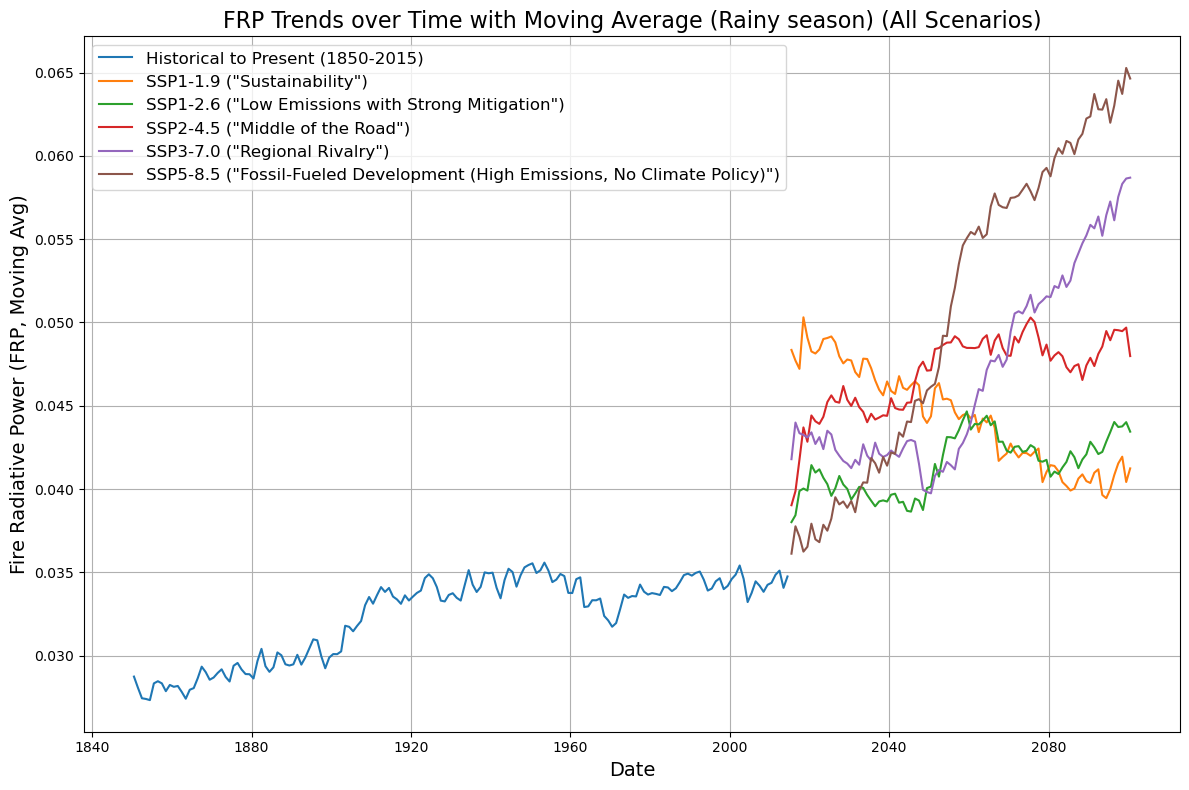

In [8]:
# Define coefficients clearly (adjust if you have scenario-specific values)
scenario_coefficients_rain = {
    'Historical to Present (1850-2015)': (0.0721, -3.0571),
    'SSP1-1.9 ("Sustainability")': (0.0721, -3.0571),
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")': (0.0721, -3.0571),
    'SSP2-4.5 ("Middle of the Road")': (0.0721, -3.0571),
    'SSP3-7.0 ("Regional Rivalry")': (0.0721, -3.0571),
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")': (0.0721, -3.0571)
}

# Plot FRP trends clearly with moving average
plot_frp_trends_moving_average(
    datasets_all_scenarios,
    labels_all_scenarios,
    scenario_coefficients_rain,
    'FRP Trends over Time with Moving Average (Rainy season) (All Scenarios)',
    window=60  # 12-month moving average (adjust as desired)
)

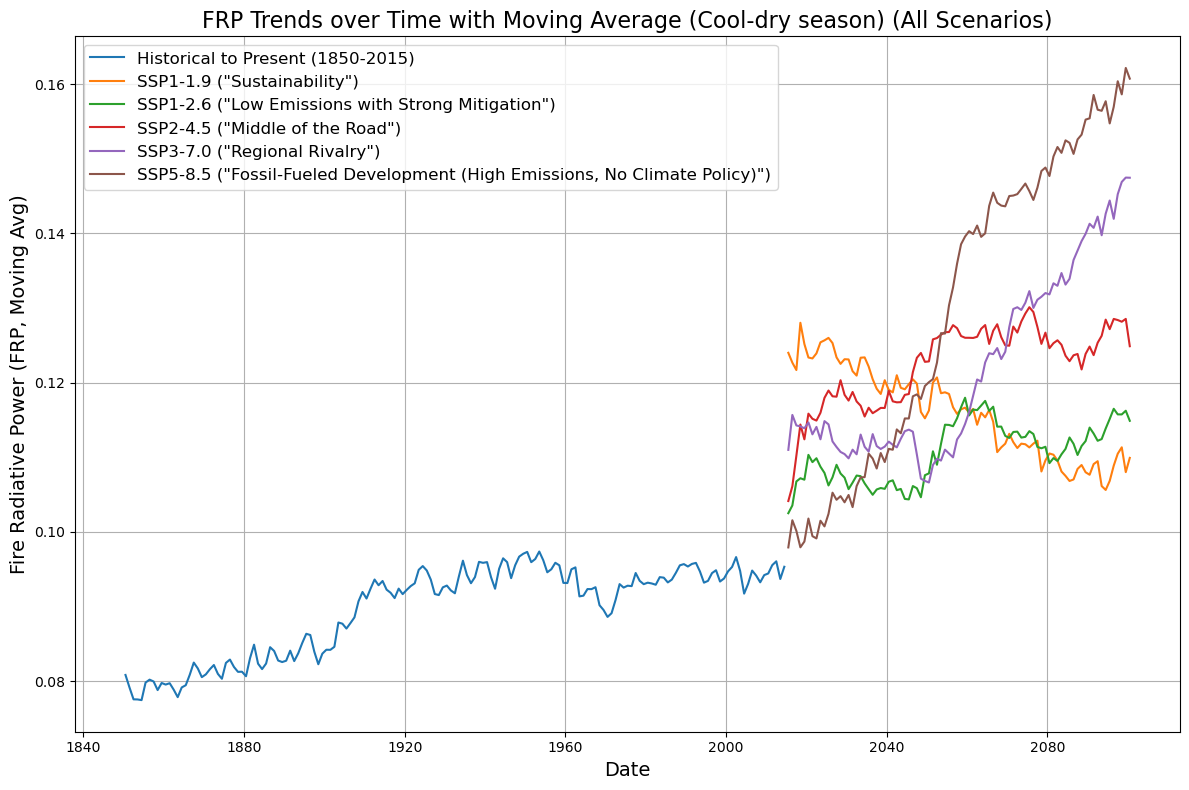

In [9]:
# Define coefficients clearly (adjust if you have scenario-specific values)
scenario_coefficients_cooldry = {
    'Historical to Present (1850-2015)': (0.0602, -2.3434),
    'SSP1-1.9 ("Sustainability")': (0.0602, -2.3434),
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")': (0.0602, -2.3434),
    'SSP2-4.5 ("Middle of the Road")': (0.0602, -2.3434),
    'SSP3-7.0 ("Regional Rivalry")': (0.0602, -2.3434),
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")': (0.0602, -2.3434)
}

# Plot FRP trends clearly with moving average
plot_frp_trends_moving_average(
    datasets_all_scenarios,
    labels_all_scenarios,
    scenario_coefficients_cooldry,
    'FRP Trends over Time with Moving Average (Cool-dry season) (All Scenarios)',
    window=60  # 12-month moving average (adjust as desired)
)

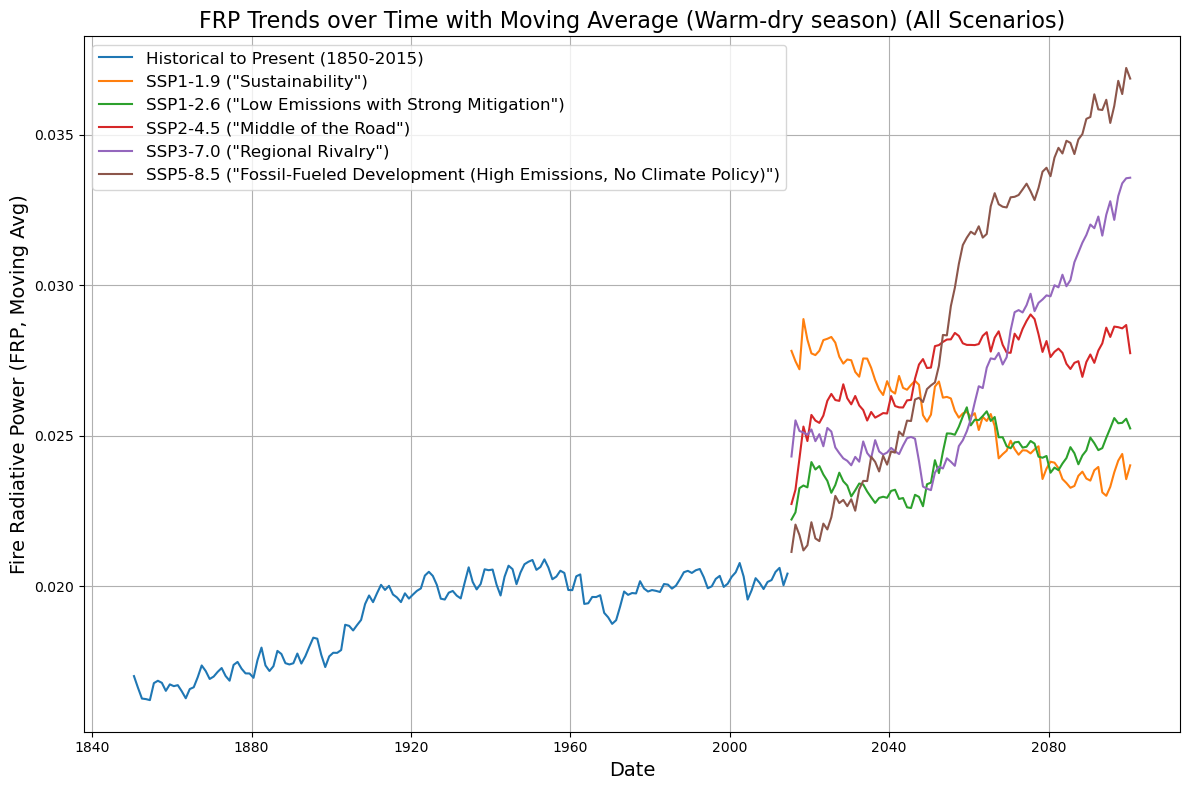

In [10]:
def calculate_frp_from_fwi(A, b, fwi_values):
    return 10 ** (A * fwi_values + b)

def plot_frp_trends_moving_average(datasets, labels, coefficients, title, window=12):
    plt.figure(figsize=(12, 8))

    for dataset, label in zip(datasets, labels):
        # Convert cftime.DatetimeNoLeap to Python datetime
        time_data = [datetime(t.year, t.month, t.day) for t in dataset['time'].values]

        # Calculate mean FWI over Thailand
        fwi_mean = dataset['fwisa'].where(
            (dataset.lat >= 5) & (dataset.lat <= 21) &
            (dataset.lon >= 97) & (dataset.lon <= 106),
            drop=True
        ).mean(dim=['lat', 'lon']).values

        # Use the same coefficients for all scenarios
        A, b = coefficients
        frp_mean = calculate_frp_from_fwi(A, b, fwi_mean)

        # Compute moving average
        frp_series = pd.Series(frp_mean)
        frp_ma = frp_series.rolling(window=window, center=True, min_periods=1).mean()

        # Plot moving average
        plt.plot(time_data, frp_ma, label=label)

    # Customize plot
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP, Moving Avg)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid()
    plt.tight_layout()
    plt.show()

# **Define a single coefficient set for all scenarios**
global_coefficients = (0.0685, -3.2044)  # Same A and B for all scenarios

# **Group datasets and labels**
datasets_all_scenarios = [
    dataset_historical, dataset_SSP119, dataset_SSP126, 
    dataset_SSP245, dataset_SSP370, dataset_SSP585
]

labels_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability")',
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road")',
    'SSP3-7.0 ("Regional Rivalry")',
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")'
]

# **Run the function**
plot_frp_trends_moving_average(
    datasets_all_scenarios,
    labels_all_scenarios,
    global_coefficients,
    'FRP Trends over Time with Moving Average (Warm-dry season) (All Scenarios)',
    window=60  # 12-month moving average
)


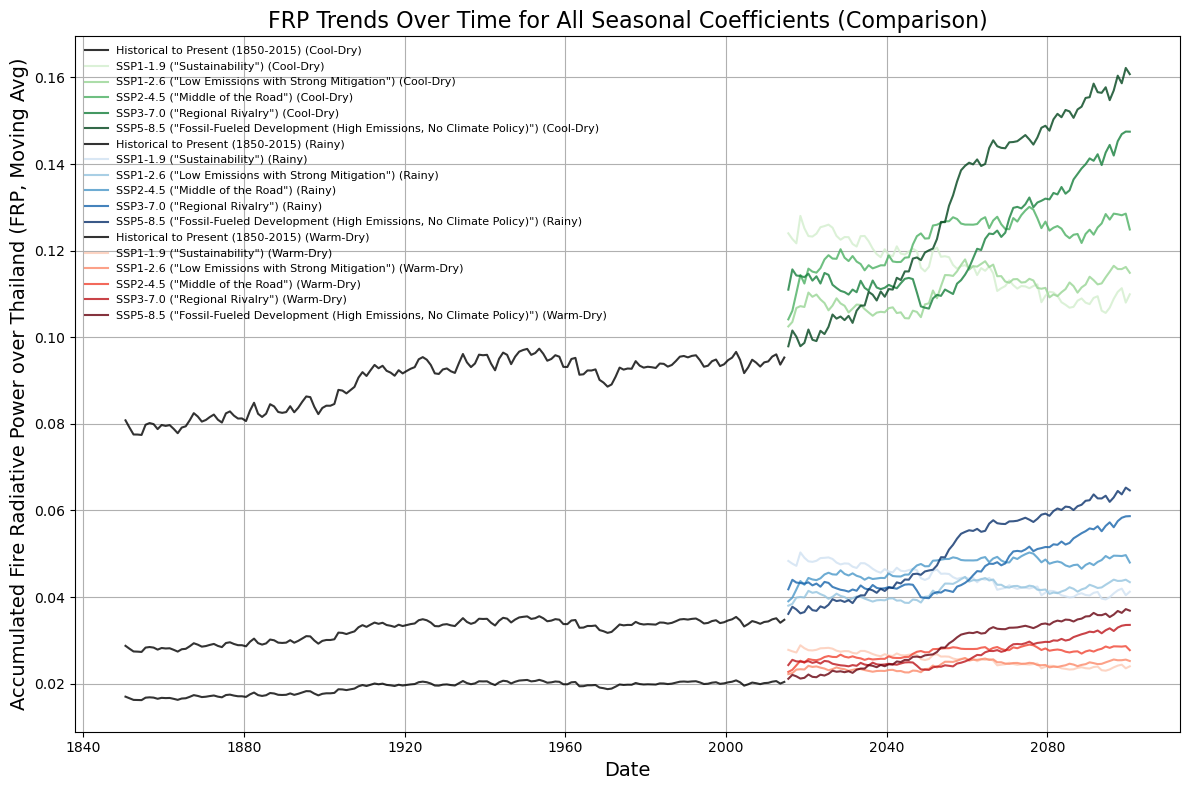

In [11]:
def calculate_frp_from_fwi(A, B, fwi_values):
    return 10 ** (A * fwi_values + B)

def plot_frp_trends_all_seasons(datasets, labels, seasonal_coefficients, title, window=12):
    plt.figure(figsize=(12, 8))

    season_colors = {
        'Cool-Dry': 'Greens',
        'Rainy': 'Blues',
        'Warm-Dry': 'Reds'
    }

    num_scenarios = len(labels)

    for season, (A, B) in seasonal_coefficients.items():
        colormap = plt.colormaps.get_cmap(season_colors[season])  # Get colormap
        color_shades = [colormap(i / (num_scenarios - 1)) for i in range(num_scenarios)]  # Generate shades

        for i, (dataset, label) in enumerate(zip(datasets, labels)):
            time_data = [datetime(t.year, t.month, t.day) for t in dataset['time'].values]

            # Calculate mean FWI over Thailand
            fwi_mean = dataset['fwisa'].where(
                (dataset.lat >= 5) & (dataset.lat <= 21) &
                (dataset.lon >= 97) & (dataset.lon <= 106),
                drop=True
            ).mean(dim=['lat', 'lon']).values

            # Convert FWI to FRP for the current season
            frp_mean = calculate_frp_from_fwi(A, B, fwi_mean)

            # Compute moving average
            frp_series = pd.Series(frp_mean)
            frp_ma = frp_series.rolling(window=window, center=True, min_periods=1).mean()

            # Assign different shades within the same colormap
            if "Historical" in label:
                color = "black"  # Keep historical data black
            else:
                color = color_shades[i]
            

            # Plot moving average for each scenario
            plt.plot(time_data, frp_ma, label=f"{label} ({season})", color=color, alpha=0.8)

    # Customize plot
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Accumulated Fire Radiative Power over Thailand (FRP, Moving Avg)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=8, loc='upper left', frameon=False)  # Reduce legend size
    plt.grid()
    plt.tight_layout()
    plt.show()

# **Define seasonal coefficients**
seasonal_coefficients = {
    'Cool-Dry': (0.0602, -2.3434),
    'Rainy': (0.0721, -3.0571),
    'Warm-Dry': (0.0685, -3.2044)
}

# **Group datasets and labels**
datasets_all_scenarios = [
    dataset_historical, dataset_SSP119, dataset_SSP126, 
    dataset_SSP245, dataset_SSP370, dataset_SSP585
]

labels_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability")',
    'SSP1-2.6 ("Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road")',
    'SSP3-7.0 ("Regional Rivalry")',
    'SSP5-8.5 ("Fossil-Fueled Development (High Emissions, No Climate Policy)")'
]

# **Run the function**
plot_frp_trends_all_seasons(
    datasets_all_scenarios,
    labels_all_scenarios,
    seasonal_coefficients,
    'FRP Trends Over Time for All Seasonal Coefficients (Comparison)',
    window=60  # 12-month moving average
)


In [33]:
datasets_thailand = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios if isinstance(ds, xr.Dataset)
]

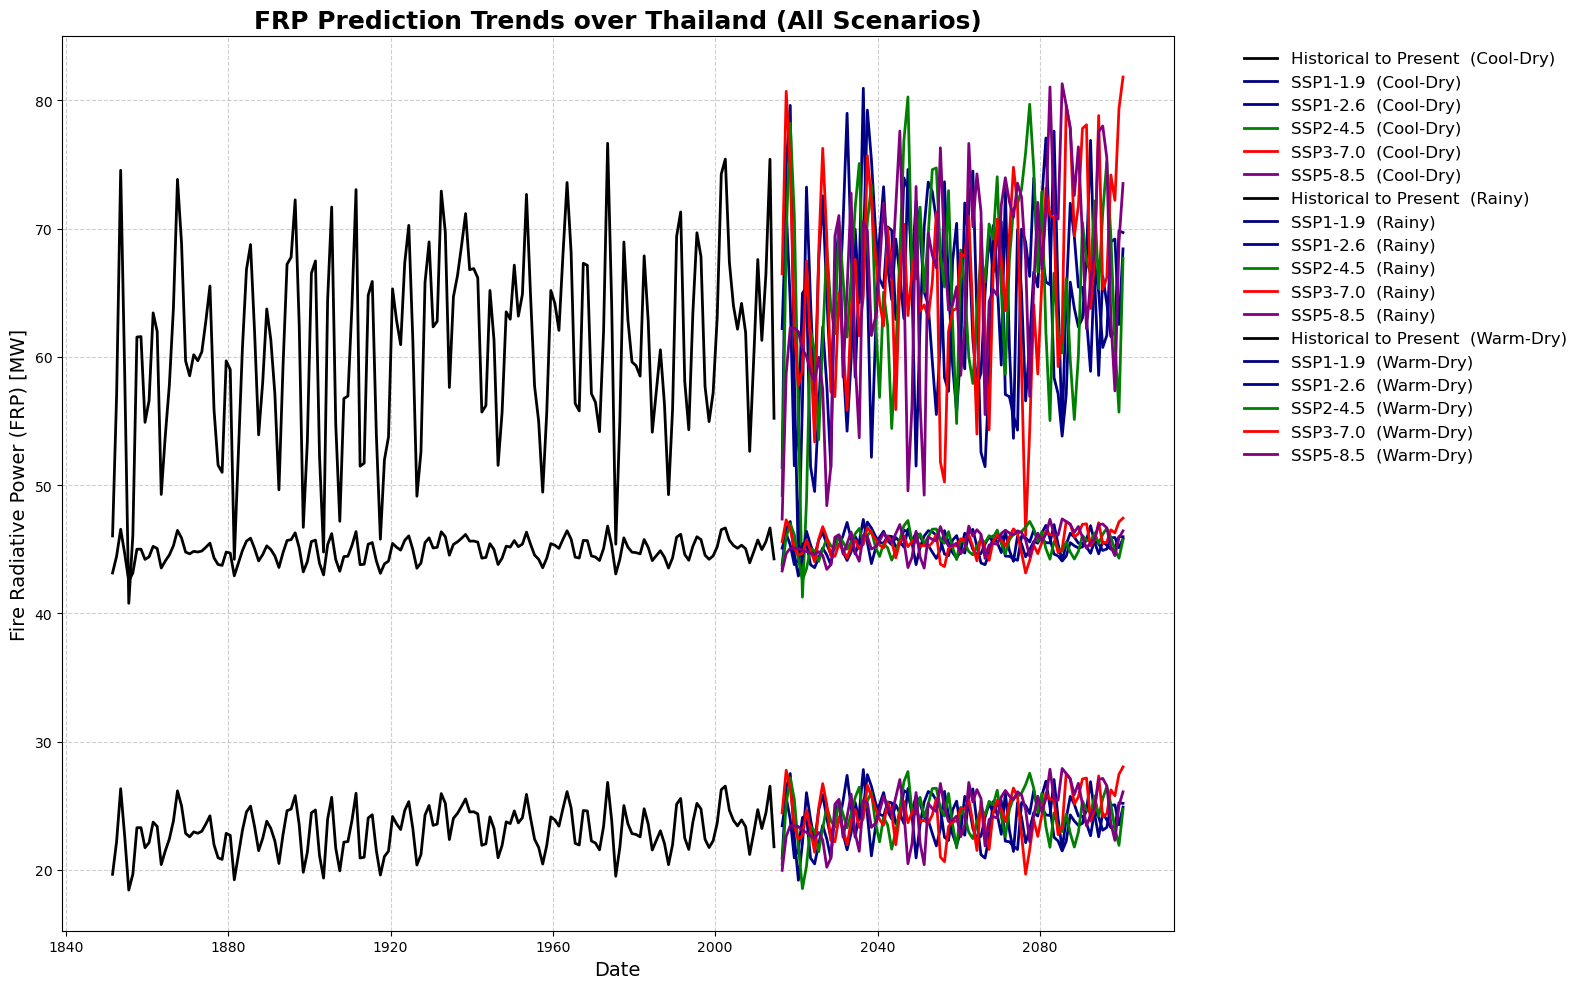

In [69]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cftime

def plot_frp_trends_linear(datasets, title, seasonal_coeffs, window_size):
    """ 
    Plot FRP trends over time for given datasets using season-specific coefficients.

    Args:
        datasets (list): List of xarray datasets (each corresponding to a different SSP scenario).
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()

    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    base_colors = {"Cool-Dry": "blue", "Rainy": "green", "Warm-Dry": "red"}
    
    selected_scenarios = {
        "Historical to Present ": "black",
        'SSP1-1.9 ': "navy",
        'SSP1-2.6 ': "darkblue",
        'SSP2-4.5 ': "green",
        'SSP3-7.0 ': "red",
        'SSP5-8.5 ': "purple"
    }
    
    plt.figure(figsize=(16, 10))  # Increase figure size for better visibility

    for season in seasons:
        C, D = seasonal_coeffs[season]  

        for dataset, (label, color_shade) in zip(datasets, selected_scenarios.items()):
            fwi_mean = dataset['fwisa'].where(
                (dataset.lat >= 5) & (dataset.lat <= 21) &
                (dataset.lon >= 97) & (dataset.lon <= 106),
                drop=True
            ).mean(dim=['lat', 'lon']).values  

            time = dataset.coords.get('time', None)
            if time is not None:
                if isinstance(time.values[0], cftime.DatetimeNoLeap):
                    time = np.array([np.datetime64(t.strftime('%Y-%m-%d')) for t in time.values])
                else:
                    time = np.array(time.values, dtype='datetime64[ns]')  

                frp_values = C * fwi_mean + D  
                smoothed_frp = moving_average(xr.DataArray(frp_values, dims=["time"]), window_size).values
                
                plt.plot(time, smoothed_frp, color=color_shade, linewidth=2, label=f'{label} ({season})')

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP) [MW]', fontsize=14)
    plt.title(title, fontsize=18, fontweight="bold")

    # **Better Legend Formatting**
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False, ncol=1)  # Multi-column legend

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
# **Scenario-specific coefficients**
seasonal_coefficients_frp_10years = {
    'Warm-Dry': (0.2790, 39.2341),
    'Rainy': (2.3345, 13.2520),
    'Cool-Dry': (0.5463, 11.9846)
}

# **Run the modified function**
plot_frp_trends_linear(
    datasets_thailand,  
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frp_10years,
    window_size=2
)


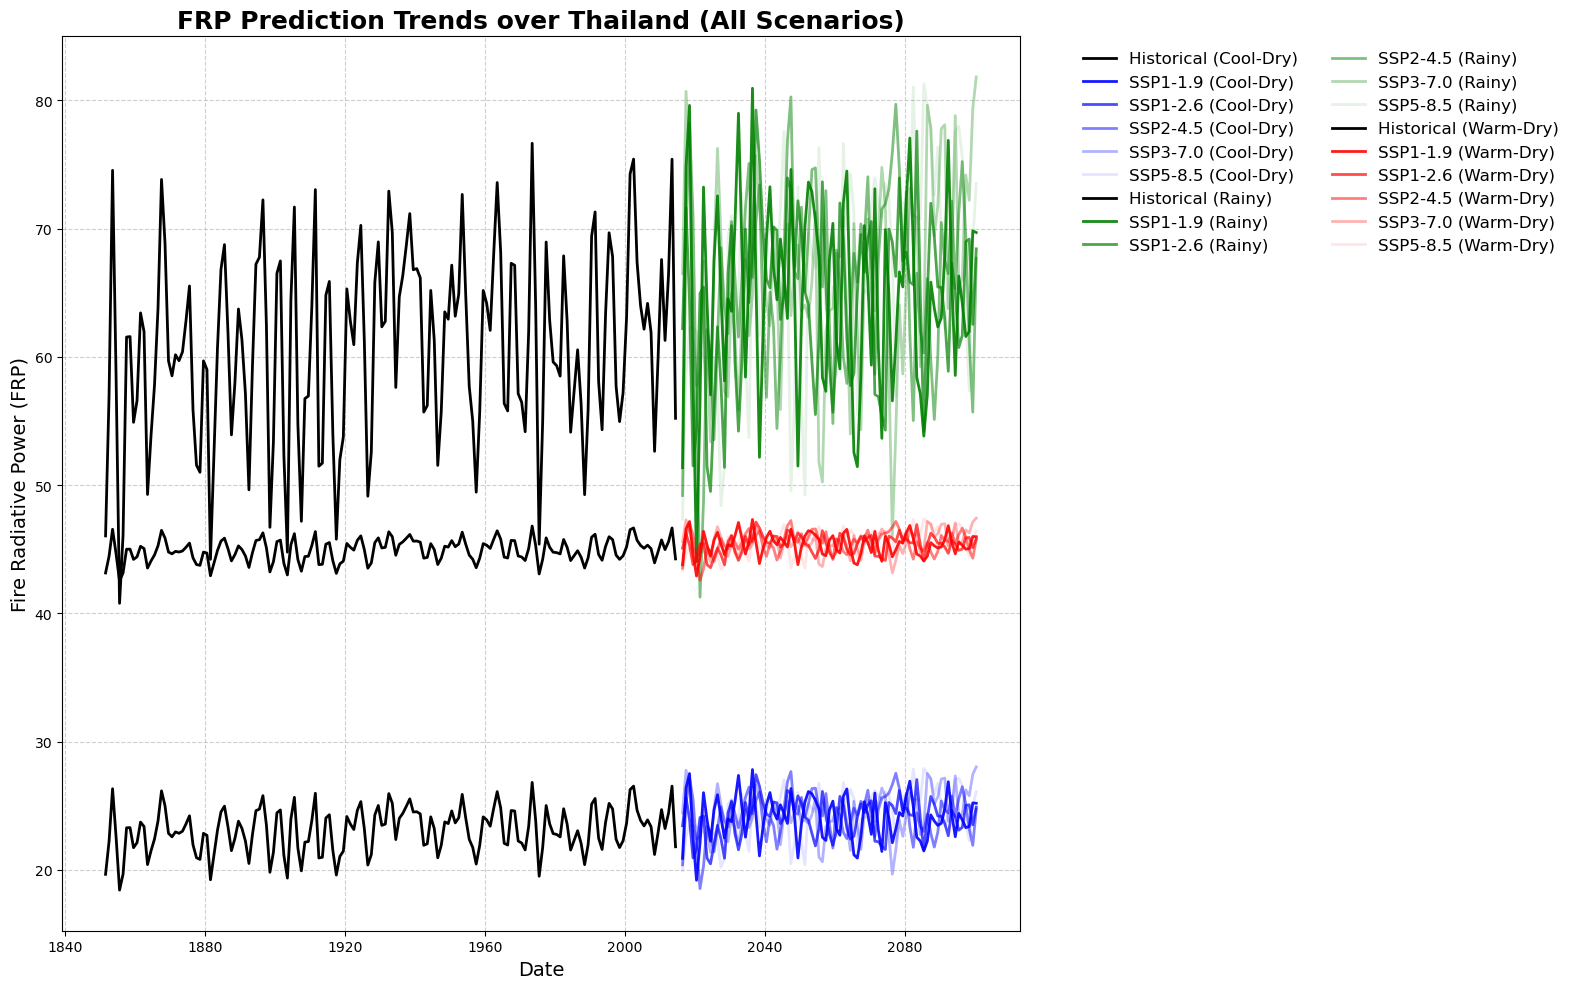

In [71]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cftime

def plot_frp_trends_linear(datasets, title, seasonal_coeffs, window_size):
    """ 
    Plot FRP trends over time for given datasets using season-specific coefficients.

    Args:
        datasets (list): List of xarray datasets (each corresponding to a different SSP scenario).
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()

    # Define base colors for seasons
    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    base_colors = {"Cool-Dry": "blue", "Rainy": "green", "Warm-Dry": "red"}
    
    # Define SSP scenario shades
    color_shades = {
        "Historical": "black",  
        "SSP119": 0.9,
        "SSP126": 0.7,
        "SSP245": 0.5,
        "SSP370": 0.3,
        "SSP585": 0.1
    }

    # Shortened labels
    selected_scenarios = {
        "Historical": "Historical",
        "SSP119": "SSP1-1.9",
        "SSP126": "SSP1-2.6",
        "SSP245": "SSP2-4.5",
        "SSP370": "SSP3-7.0",
        "SSP585": "SSP5-8.5"
    }

    plt.figure(figsize=(16, 10))  # Increase figure size

    for season in seasons:
        C, D = seasonal_coeffs[season]  
        base_color = base_colors[season]  # Assign the season's base color

        for dataset, (ssp, label) in zip(datasets, selected_scenarios.items()):
            fwi_mean = dataset['fwisa'].where(
                (dataset.lat >= 5) & (dataset.lat <= 21) &
                (dataset.lon >= 97) & (dataset.lon <= 106),
                drop=True
            ).mean(dim=['lat', 'lon']).values  

            time = dataset.coords.get('time', None)
            if time is not None:
                if isinstance(time.values[0], cftime.DatetimeNoLeap):
                    time = np.array([np.datetime64(t.strftime('%Y-%m-%d')) for t in time.values])
                else:
                    time = np.array(time.values, dtype='datetime64[ns]')  

                frp_values = C * fwi_mean + D  
                smoothed_frp = moving_average(xr.DataArray(frp_values, dims=["time"]), window_size).values
                
                # Apply base color with different shades based on SSP
                line_color = "black" if ssp == "Historical" else mcolors.to_rgba(base_color, color_shades[ssp])
                
                plt.plot(time, smoothed_frp, color=line_color, linewidth=2, label=f'{label} ({season})')

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP)', fontsize=14)
    plt.title(title, fontsize=18, fontweight="bold")

    # **Better Legend Formatting**
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False, ncol=2)  # Multi-column legend

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
# **Scenario-specific coefficients**
seasonal_coefficients_frp_10years = {
    'Warm-Dry': (0.2790, 39.2341),
    'Rainy': (2.3345, 13.2520),
    'Cool-Dry': (0.5463, 11.9846)
}

# **Run the modified function**
plot_frp_trends_linear(
    datasets_thailand,  
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frp_10years,
    window_size=2
)


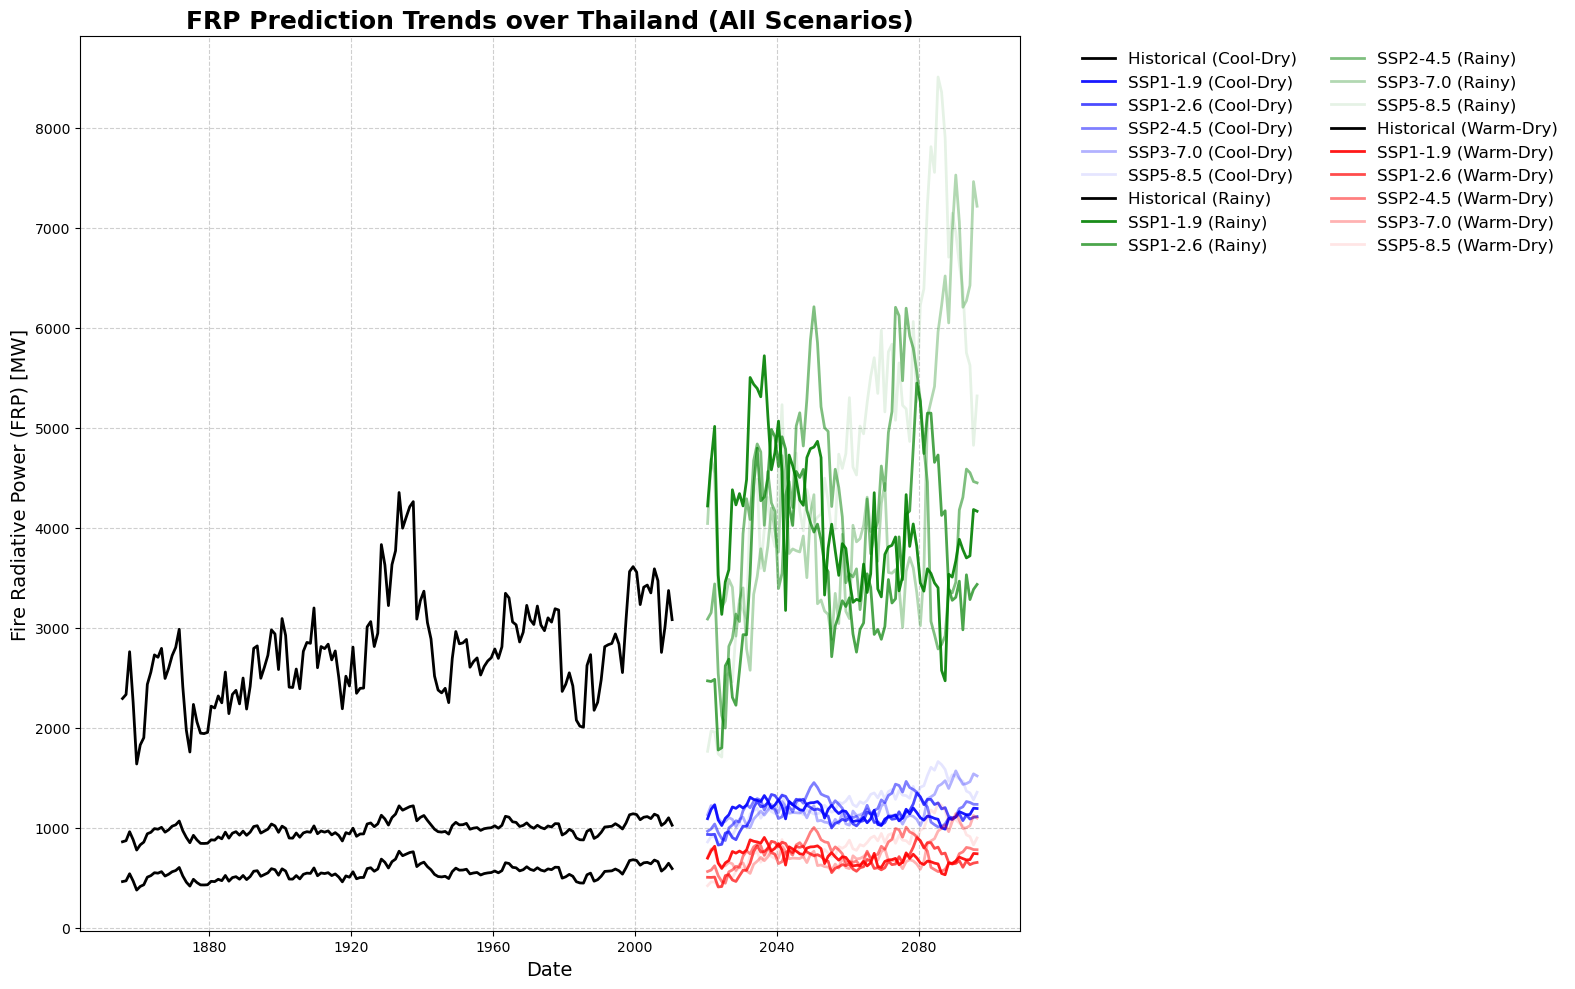

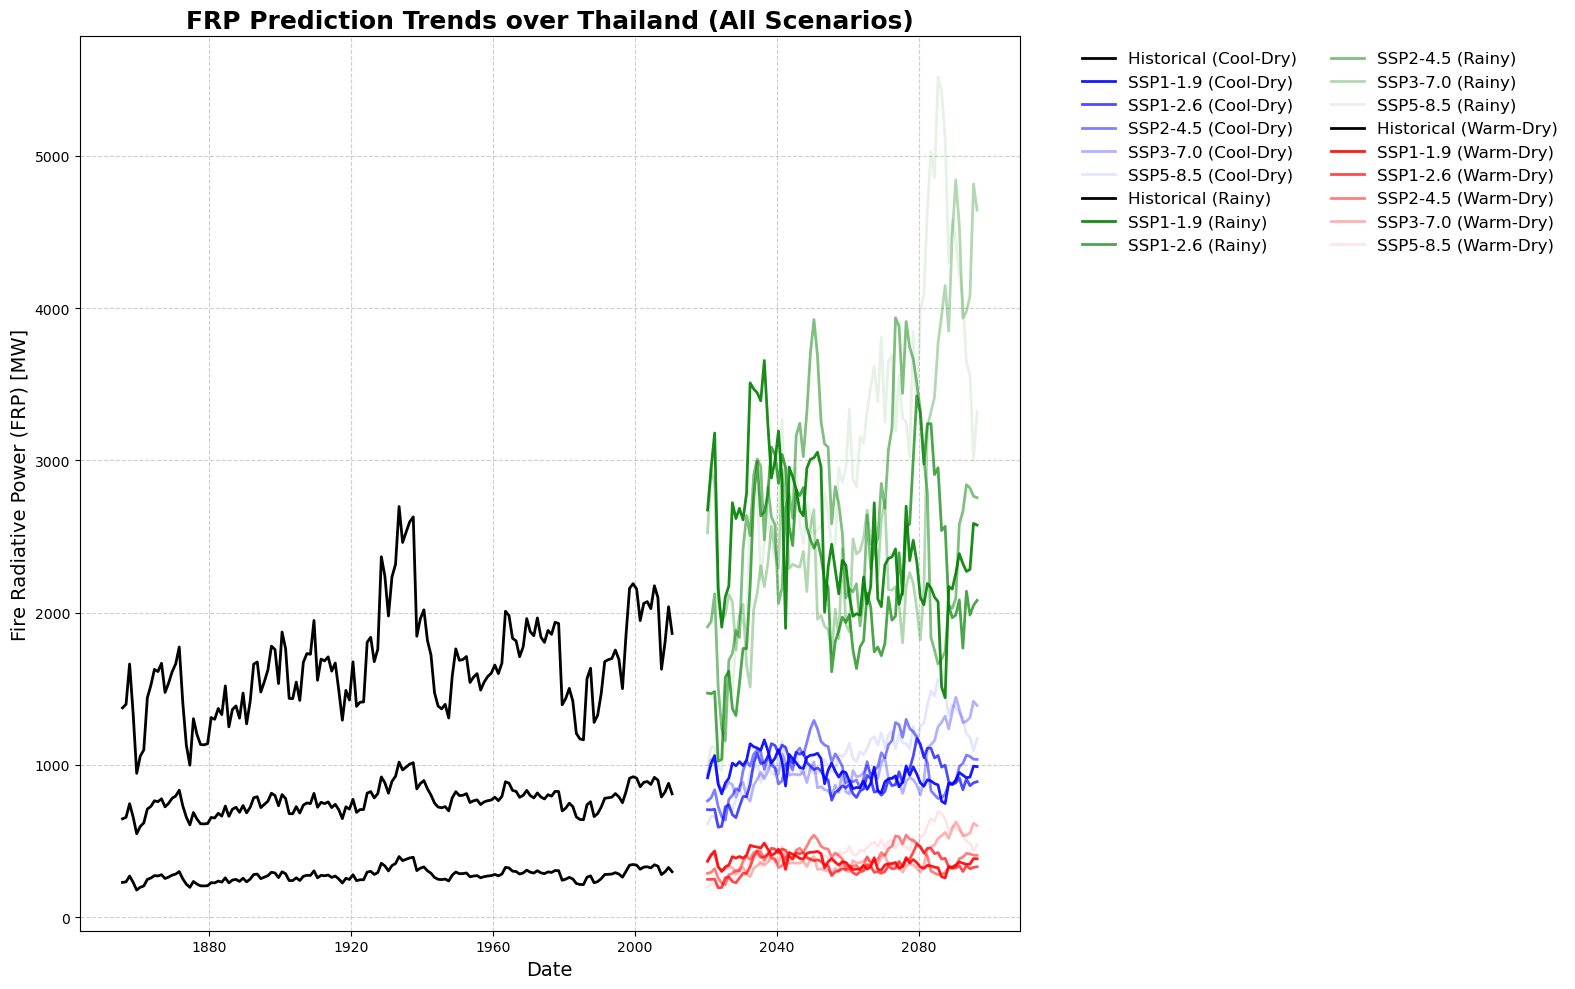

In [79]:
def plot_frp_trends(datasets, title, seasonal_coeffs, window_size):
    """ 
    Plot FRP trends over time for given datasets using season-specific coefficients.

    Args:
        datasets (list): List of xarray datasets (each corresponding to a different SSP scenario).
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()

    # Define base colors for seasons
    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    base_colors = {"Cool-Dry": "blue", "Rainy": "green", "Warm-Dry": "red"}
    
    # Define SSP scenario shades
    color_shades = {
        "Historical": "black",  
        "SSP119": 0.9,
        "SSP126": 0.7,
        "SSP245": 0.5,
        "SSP370": 0.3,
        "SSP585": 0.1
    }

    # Shortened labels
    selected_scenarios = {
        "Historical": "Historical",
        "SSP119": "SSP1-1.9",
        "SSP126": "SSP1-2.6",
        "SSP245": "SSP2-4.5",
        "SSP370": "SSP3-7.0",
        "SSP585": "SSP5-8.5"
    }

    plt.figure(figsize=(16, 10))  # Increase figure size

    for season in seasons:
        C, D = seasonal_coeffs[season]  
        base_color = base_colors[season]  # Assign the season's base color

        for dataset, (ssp, label) in zip(datasets, selected_scenarios.items()):
            fwi_mean = dataset['fwisa'].where(
                (dataset.lat >= 5) & (dataset.lat <= 21) &
                (dataset.lon >= 97) & (dataset.lon <= 106),
                drop=True
            ).mean(dim=['lat', 'lon']).values  

            time = dataset.coords.get('time', None)
            if time is not None:
                if isinstance(time.values[0], cftime.DatetimeNoLeap):
                    time = np.array([np.datetime64(t.strftime('%Y-%m-%d')) for t in time.values])
                else:
                    time = np.array(time.values, dtype='datetime64[ns]')  

                frp_values = 10**(C * fwi_mean + D)
                smoothed_frp = moving_average(xr.DataArray(frp_values, dims=["time"]), window_size).values
                
                # Apply base color with different shades based on SSP
                line_color = "black" if ssp == "Historical" else mcolors.to_rgba(base_color, color_shades[ssp])
                
                plt.plot(time, smoothed_frp, color=line_color, linewidth=2, label=f'{label} ({season})')

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP) [MW]', fontsize=14)
    plt.title(title, fontsize=18, fontweight="bold")

    # **Better Legend Formatting**
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False, ncol=2)  # Multi-column legend

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
seasonal_coefficients_frpDAY = {
    'Warm-Dry': (0.0599, 1.4524),
    'Rainy': (0.0854, 1.5648),
    'Cool-Dry': (0.0369, 2.2171)
}

seasonal_coefficients_frpNight = {
    'Warm-Dry': (0.0686, 0.9521),
    'Rainy': (0.0924, 1.1772),
    'Cool-Dry': (0.0518, 1.7766)
}

# **Run the modified function**
plot_frp_trends(
    datasets_thailand,  
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frpDAY,
    window_size=10
)
# **Run the modified function**
plot_frp_trends(
    datasets_thailand,  
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frpNight,
    window_size=10
)

In [89]:
def plot_frp_trends_dot(datasets, title, seasonal_coeffs, window_size):
    """ 
    Plot FRP trends over time for given datasets using season-specific coefficients.

    Args:
        datasets (list): List of xarray datasets (each corresponding to a different SSP scenario).
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()

    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    base_colors = {"Cool-Dry": "blue", "Rainy": "green", "Warm-Dry": "red"}
    
    selected_scenarios = {
        "Historical to Present ": "black",
        'SSP1-1.9 ': "navy",
        'SSP1-2.6 ': "darkblue",
        'SSP2-4.5 ': "green",
        'SSP3-7.0 ': "red",
        'SSP5-8.5 ': "purple"
    }
    
    plt.figure(figsize=(16, 10))  # Increase figure size for better visibility

    for season in seasons:
        C, D = seasonal_coeffs[season]  

        for dataset, (label, color_shade) in zip(datasets, selected_scenarios.items()):
            fwi_mean = dataset['fwisa'].where(
                (dataset.lat >= 5) & (dataset.lat <= 21) &
                (dataset.lon >= 97) & (dataset.lon <= 106),
                drop=True
            ).mean(dim=['lat', 'lon']).values  

            time = dataset.coords.get('time', None)
            if time is not None:
                if isinstance(time.values[0], cftime.DatetimeNoLeap):
                    time = np.array([np.datetime64(t.strftime('%Y-%m-%d')) for t in time.values])
                else:
                    time = np.array(time.values, dtype='datetime64[ns]')  

                frp_values = 10**(C * fwi_mean + D)
                smoothed_frp = moving_average(xr.DataArray(frp_values, dims=["time"]), window_size).values
                
                plt.plot(time, smoothed_frp, color=color_shade, linewidth=2, label=f'{label} ({season})')

    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP) [MW]', fontsize=14)
    plt.title(title, fontsize=18, fontweight="bold")

    # **Better Legend Formatting**
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False, ncol=1)  # Multi-column legend

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

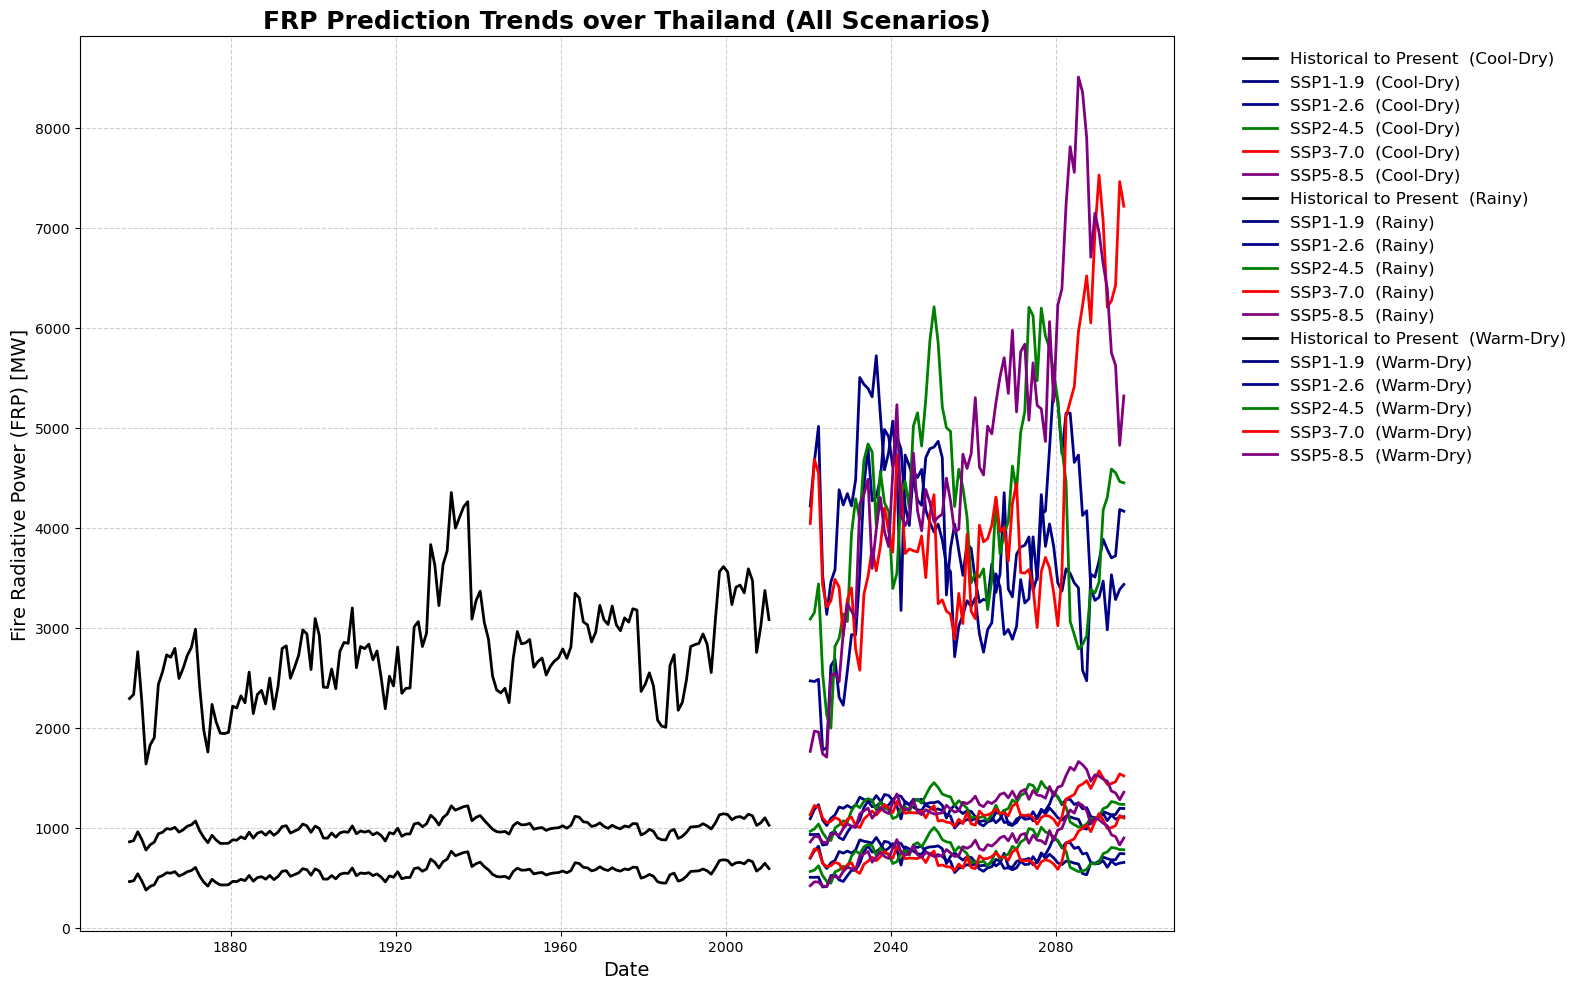

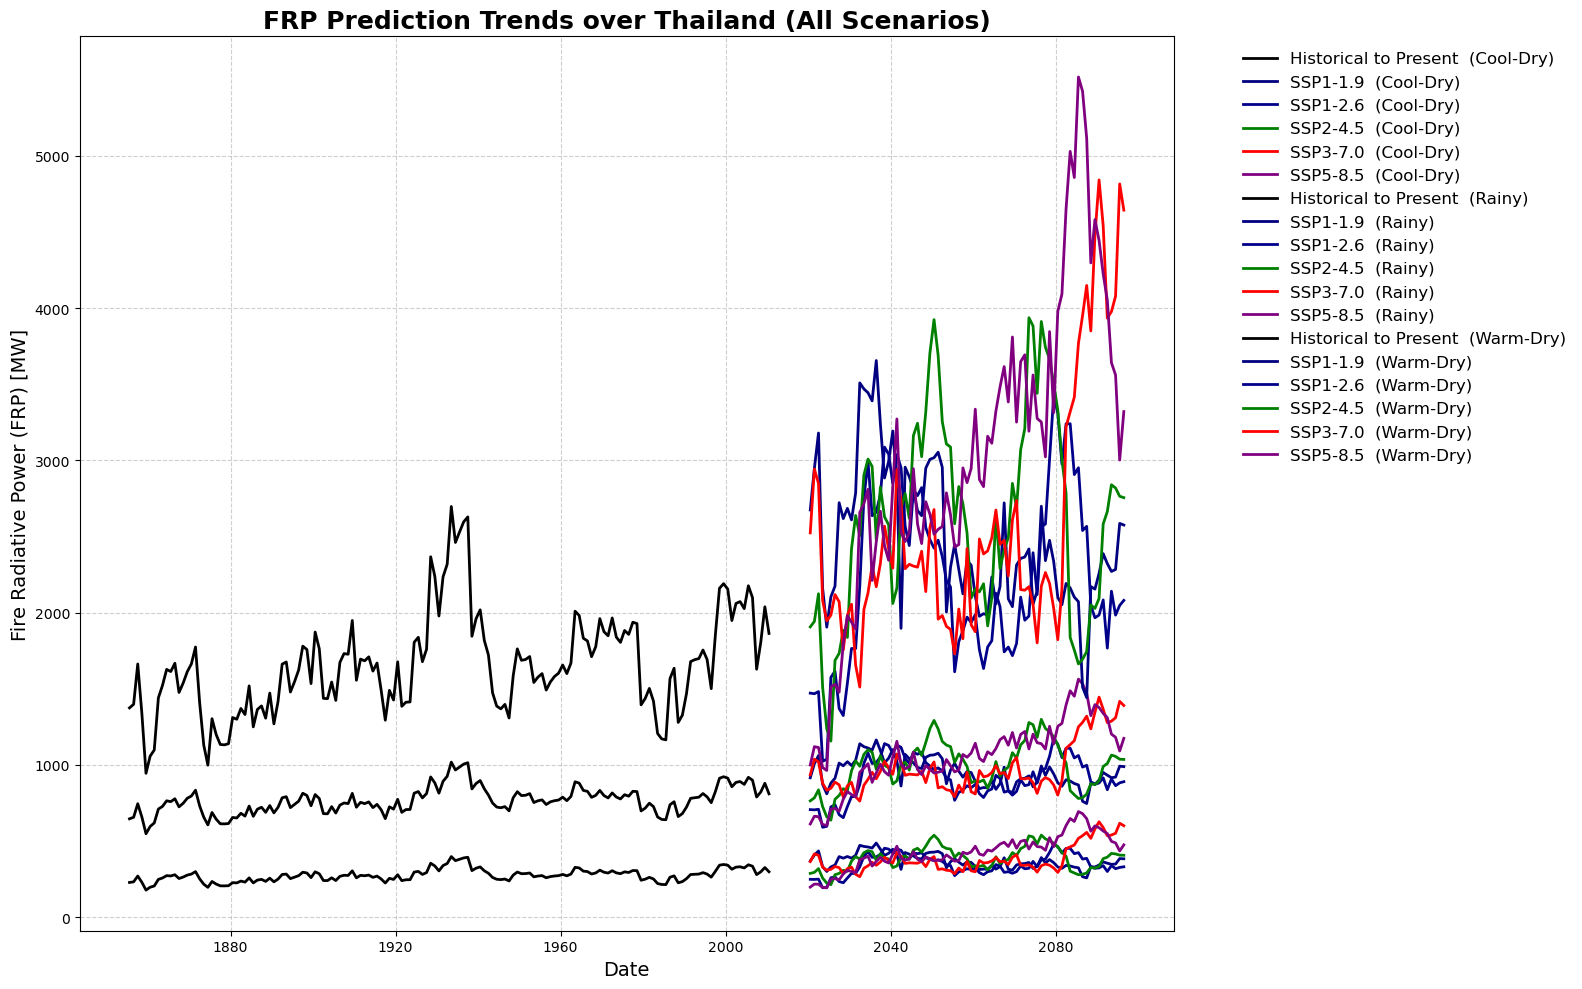

In [91]:
# **Run the modified function**
plot_frp_trends_dot(
    datasets_thailand,  
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frpDAY,
    window_size=10
)

plot_frp_trends_dot(
    datasets_thailand,  
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frpNight,
    window_size=10
)